# Load dataset

In [1]:
import pandas as pd

df = pd.read_csv("../../data/raw/online_retail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Dataset information, description and visualization and Clean if needed

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [4]:
df.shape

(541909, 8)

#### Missing Values

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

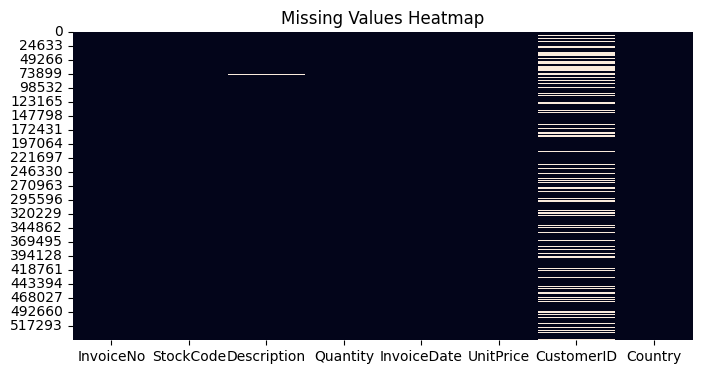

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

#### Handle Missing values

In [7]:
df = df.dropna(subset=["CustomerID"])

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Missing Value Handling

The dataset initially contained missing values in the CustomerID and Description columns.

Rows with missing CustomerID values were removed because customer identification is essential for customer segmentation, churn prediction, and RFM analysis.

After removing these records, no missing values remained in the dataset.

#

#### Handle Duplicate rows

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5225


In [10]:
df = df.drop_duplicates()

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Duplicate Record Handling

The dataset was examined for duplicate records using the Pandas `duplicated()` function.

A total of 5268 duplicate rows were identified and removed to improve data quality and prevent bias in downstream analysis and machine learning models.

#### Handle Invalid Transactions

In [12]:
df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

In [13]:
df.shape

(392692, 8)

### Invalid transactions Handling

Records with non-positive quantities and unit prices were successfully removed.

This ensures that only valid sales transactions are used for revenue calculations, customer analytics, demand forecasting, and inventory optimization.

#### Date Conversion

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.0 MB


#### Revenue Feature Engineering

A new feature named `TotalPrice` is created by multiplying the quantity purchased by the unit price.

This feature represents the revenue generated from each transaction and will be used in customer segmentation, revenue analysis, and forecasting models.

In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


#### Revenue

In [19]:
print("Total Revenue:", df['TotalPrice'].sum())

print("Average Order Value:",
      df['TotalPrice'].mean())

Total Revenue: 8887208.894
Average Order Value: 22.6314997351614


#### Top Customers

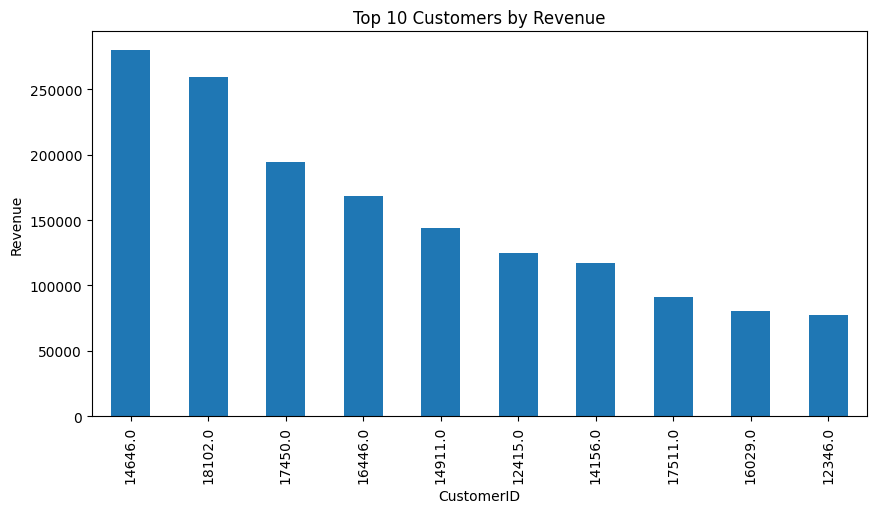

In [20]:
top_customers = (
    df.groupby('CustomerID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.show()

#### Top Countries

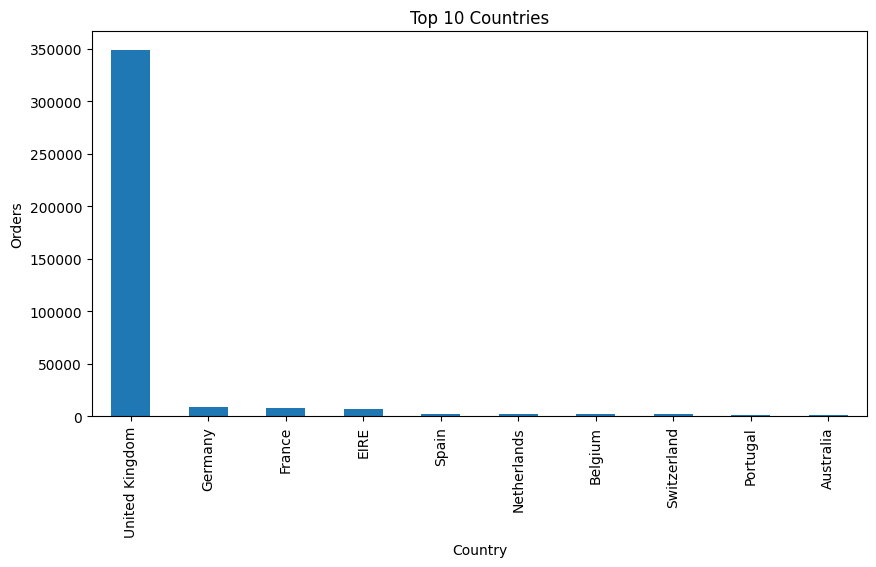

In [21]:
import matplotlib.pyplot as plt

top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Orders")

plt.show()

#### Monthly Trends

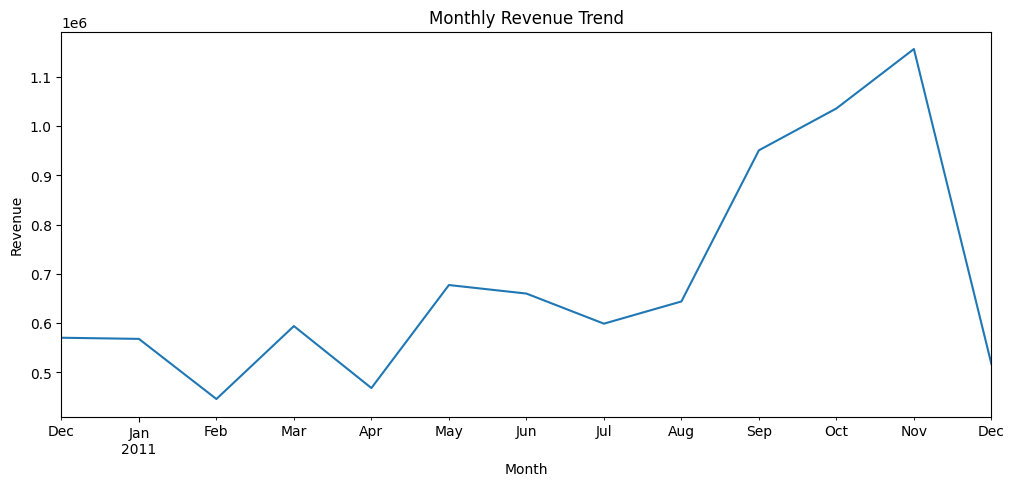

In [22]:
import matplotlib.pyplot as plt

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

monthly_sales = df.resample('ME', on='InvoiceDate')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

#### Top Products

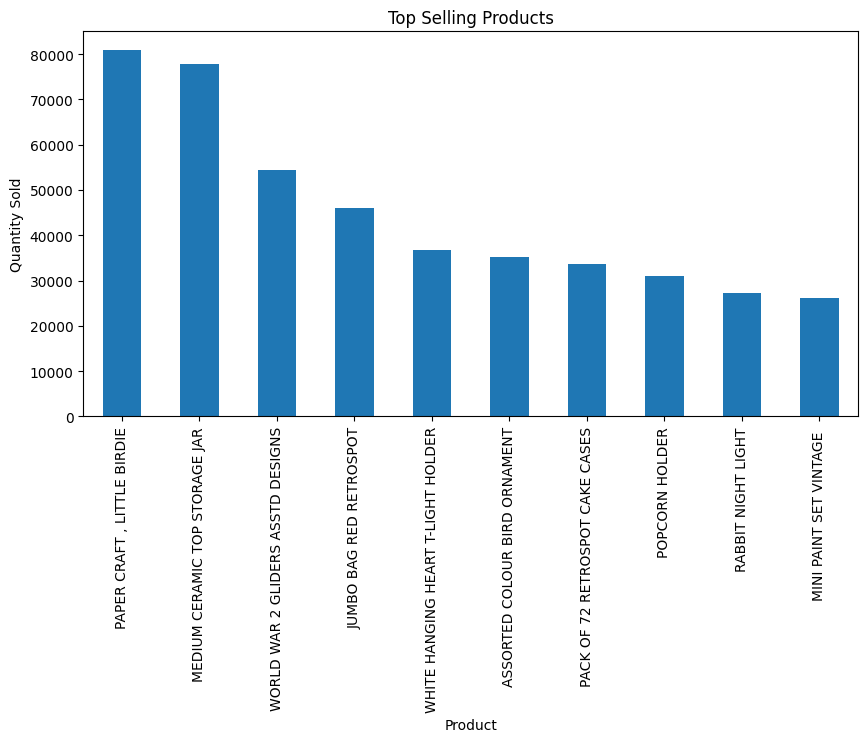

In [23]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

#### Correlation Heatmap

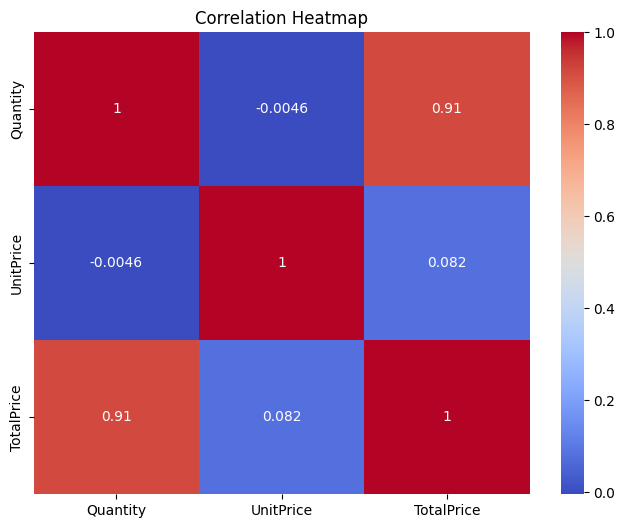

In [24]:
numeric_df = df[['Quantity', 'UnitPrice', 'TotalPrice']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

A correlation heatmap was generated using transactional variables.

CustomerID was excluded because it serves only as an identifier and does not represent a business feature.

The analysis shows that TotalPrice is positively correlated with Quantity and UnitPrice, which is expected since revenue is calculated as:

TotalPrice = Quantity × UnitPrice

## Saving the Cleaned Dataset

After handling missing values, removing duplicate records, filtering invalid transactions, and performing feature engineering, the cleaned dataset is saved for use in subsequent stages of the project.

This dataset will serve as the input for customer segmentation, demand forecasting, churn prediction, and inventory optimization tasks.

In [25]:
import os

os.makedirs("../../data/cleaned", exist_ok=True)

df.to_csv("../../data/cleaned/cleaned_retail.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


#### Rolling statistics

In [26]:
daily_sales = (
    df.resample("D", on="InvoiceDate")["TotalPrice"]
    .sum()
    .reset_index()
)

daily_sales.head()

,InvoiceDate,TotalPrice
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-04,0.00
4,2010-12-05,31361.28


In [27]:
daily_sales = (
    df.resample("D", on="InvoiceDate")["TotalPrice"]
    .sum()
    .reset_index()
)

daily_sales.head()

,InvoiceDate,TotalPrice
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-04,0.00
4,2010-12-05,31361.28


In [28]:
daily_sales["Rolling_7"] = (
    daily_sales["TotalPrice"]
    .rolling(window=7)
    .mean()
)

daily_sales["Rolling_30"] = (
    daily_sales["TotalPrice"]
    .rolling(window=30)
    .mean()
)

daily_sales.head()

,InvoiceDate,TotalPrice,Rolling_7,Rolling_30
0,2010-12-01,46192.49,NaN,NaN
1,2010-12-02,47197.57,NaN,NaN
2,2010-12-03,23876.63,NaN,NaN
3,2010-12-04,0.00,NaN,NaN
4,2010-12-05,31361.28,NaN,NaN


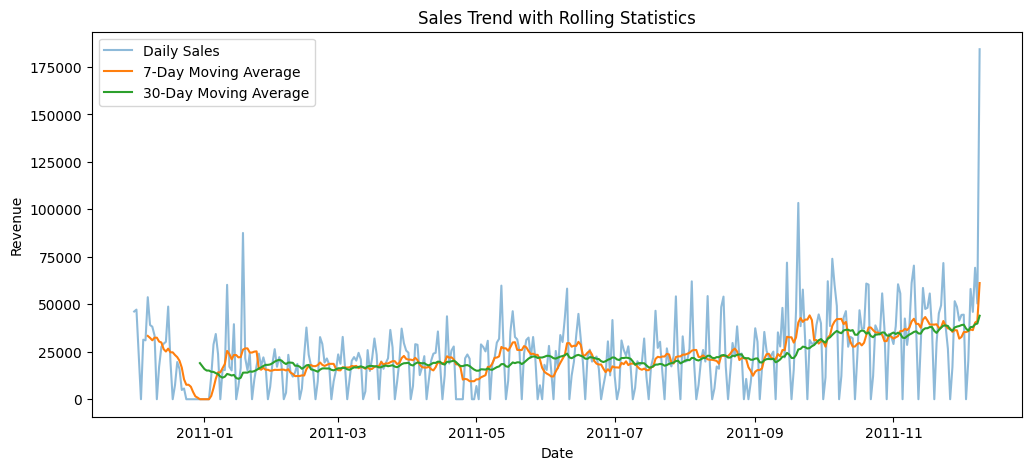

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["InvoiceDate"],
    daily_sales["TotalPrice"],
    label="Daily Sales",
    alpha=0.5
)

plt.plot(
    daily_sales["InvoiceDate"],
    daily_sales["Rolling_7"],
    label="7-Day Moving Average"
)

plt.plot(
    daily_sales["InvoiceDate"],
    daily_sales["Rolling_30"],
    label="30-Day Moving Average"
)

plt.title("Sales Trend with Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()

#### Save Rolling Sales Data

In [30]:
import os

os.makedirs("../../data/cleaned", exist_ok=True)

daily_sales.to_csv(
    "../../data/cleaned/rolling_sales.csv",
    index=False
)

print("rolling_sales.csv saved successfully!")

rolling_sales.csv saved successfully!


#### Data Validation with Great Explaination

In [31]:
%pip install great_expectations==0.18.21

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import great_expectations as gx
gx_df = gx.from_pandas(df)

In [33]:
gx_df.expect_column_values_to_not_be_null("CustomerID")

{
  "success": true,
  "result": {
    "element_count": 392692,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [34]:
gx_df.expect_column_values_to_be_between(
    "Quantity",
    min_value=1
)

{
  "success": true,
  "result": {
    "element_count": 392692,
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [35]:
gx_df.expect_column_values_to_be_between(
    "UnitPrice",
    min_value=0.001
)

{
  "success": true,
  "result": {
    "element_count": 392692,
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [36]:
gx_df.expect_column_values_to_not_be_null(
    "InvoiceDate"
)

{
  "success": true,
  "result": {
    "element_count": 392692,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [37]:
gx_df.expect_column_values_to_not_be_null(
    "TotalPrice"
)

{
  "success": true,
  "result": {
    "element_count": 392692,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [38]:
results = gx_df.validate()

print("Validation Success:", results["success"])

Validation Success: True


### Data Validation with Great Expectations

Great Expectations was used to validate the quality of the cleaned dataset.

Validation checks performed:

- CustomerID contains no missing values.
- Quantity values are positive.
- UnitPrice values are greater than or equal to 0.001.
- InvoiceDate contains no missing values.
- TotalPrice contains no missing values.

All validation rules passed successfully, indicating that the dataset is suitable for downstream machine learning and analytics tasks.